# Insurance Cross-Sell Prediction & Lead Scoring Analytics

## Objective
The objective of this project is to identify customers who are more likely to respond positively to an insurance cross-sell offer and prioritize them for sales and marketing outreach.

## Business Problem
Insurance companies often have a large number of potential customers, but sales teams cannot contact everyone with equal priority. This project uses customer information and machine learning to generate lead scores and classify customers into High, Medium, and Low priority groups.

## Dataset
The dataset contains 381,109 customer records with demographic, vehicle, premium, insurance, and sales-channel information.

## Models Used
- Logistic Regression
- Random Forest

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

In [27]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
# Cell 2: Dataset Information

print("Dataset Info:")
print("-" * 50)

df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB

Column Names:
['id', 'Gender', '

In [5]:
# Cell 3: Data Quality Check

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Duplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Response"].value_counts())

print("\nTarget Distribution (%):")
print(df["Response"].value_counts(normalize=True) * 100)

Missing Values:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

Total Duplicate Rows:
0

Target Distribution:
Response
0    334399
1     46710
Name: count, dtype: int64

Target Distribution (%):
Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64


In [6]:
# Cell 4: Statistical Summary

print("Statistical Summary:")
display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
id,381109.0,190555.000000,110016.836208,1.0,95278.0,190555.0,285832.0,381109.0
Age,381109.0,38.822584,15.511611,20.0,25.0,36.0,49.0,85.0
Driving_License,381109.0,0.997869,0.046110,0.0,1.0,1.0,1.0,1.0
Region_Code,381109.0,26.388807,13.229888,0.0,15.0,28.0,35.0,52.0
Previously_Insured,381109.0,0.458210,0.498251,0.0,0.0,0.0,1.0,1.0
Annual_Premium,381109.0,30564.389581,17213.155057,2630.0,24405.0,31669.0,39400.0,540165.0
Policy_Sales_Channel,381109.0,112.034295,54.203995,1.0,29.0,133.0,152.0,163.0
Vintage,381109.0,154.347397,83.671304,10.0,82.0,154.0,227.0,299.0
Response,381109.0,0.122563,0.327936,0.0,0.0,0.0,0.0,1.0


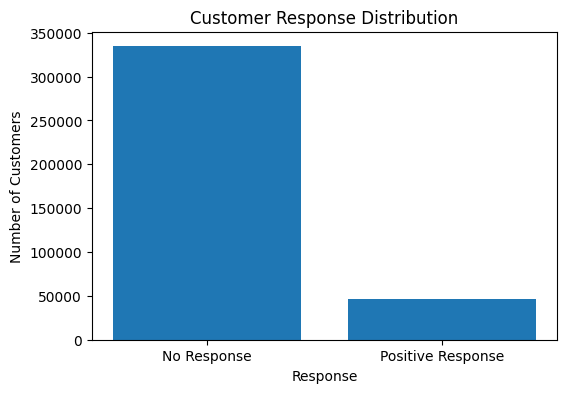

In [7]:
# Cell 5: Target Distribution

import matplotlib.pyplot as plt

response_counts = df["Response"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Response", "Positive Response"], response_counts.values)

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.show()

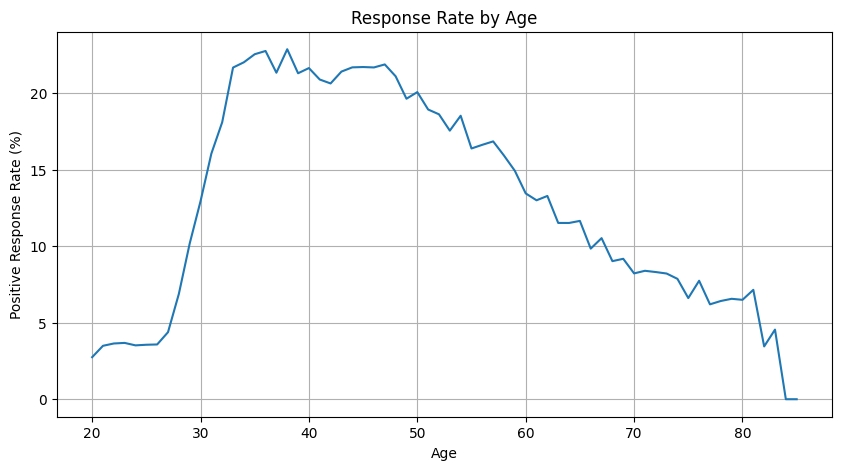

In [8]:
# Cell 6: Age vs Response

age_response = df.groupby("Age")["Response"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(age_response.index, age_response.values)

plt.title("Response Rate by Age")
plt.xlabel("Age")
plt.ylabel("Positive Response Rate (%)")

plt.grid(True)
plt.show()

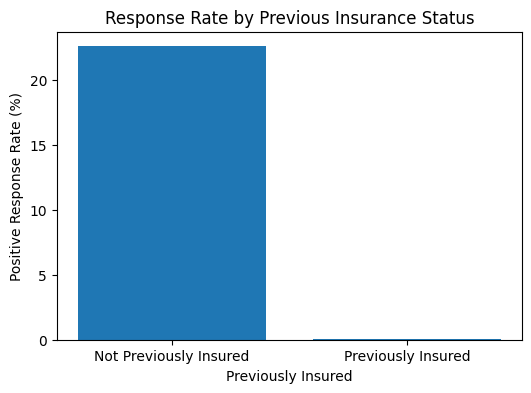

Previously_Insured
0    22.545416
1     0.090478
Name: Response, dtype: float64


In [9]:
# Cell 7: Previously Insured vs Response

insured_response = (
    df.groupby("Previously_Insured")["Response"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Not Previously Insured", "Previously Insured"],
    insured_response.values
)

plt.title("Response Rate by Previous Insurance Status")
plt.xlabel("Previously Insured")
plt.ylabel("Positive Response Rate (%)")

plt.show()

print(insured_response)

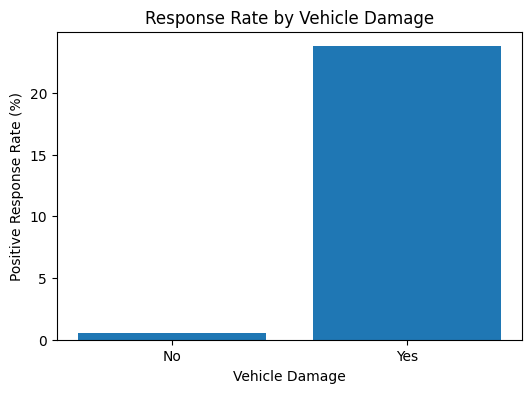

Vehicle_Damage
No      0.520414
Yes    23.765546
Name: Response, dtype: float64


In [10]:
# Cell 8: Vehicle Damage vs Response

damage_response = (
    df.groupby("Vehicle_Damage")["Response"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

plt.bar(
    damage_response.index,
    damage_response.values
)

plt.title("Response Rate by Vehicle Damage")
plt.xlabel("Vehicle Damage")
plt.ylabel("Positive Response Rate (%)")

plt.show()

print(damage_response)

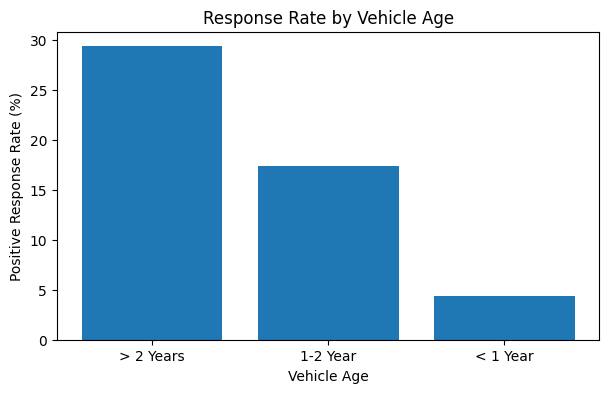

Vehicle_Age
> 2 Years    29.374649
1-2 Year     17.375547
< 1 Year      4.370517
Name: Response, dtype: float64


In [11]:
# Cell 9: Vehicle Age vs Response

vehicle_age_response = (
    df.groupby("Vehicle_Age")["Response"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))

plt.bar(
    vehicle_age_response.index,
    vehicle_age_response.values
)

plt.title("Response Rate by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Positive Response Rate (%)")

plt.show()

print(vehicle_age_response)

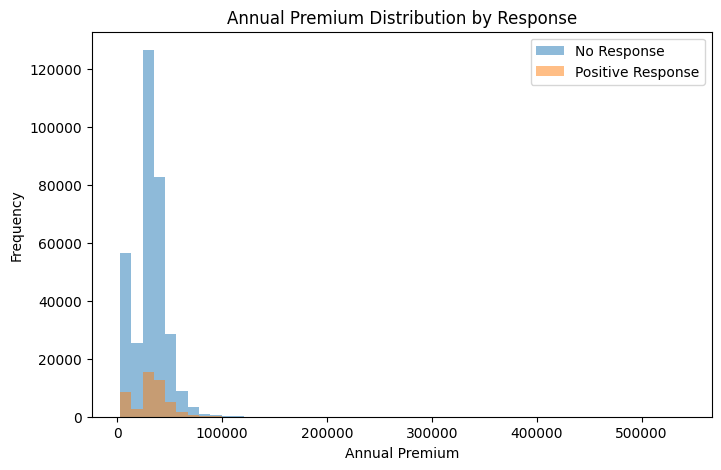

                  mean   median
Response                       
0         30419.160276  31504.0
1         31604.092742  33002.0


In [12]:
# Cell 10: Annual Premium vs Response

plt.figure(figsize=(8, 5))

df[df["Response"] == 0]["Annual_Premium"].plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    label="No Response"
)

df[df["Response"] == 1]["Annual_Premium"].plot(
    kind="hist",
    bins=50,
    alpha=0.5,
    label="Positive Response"
)

plt.title("Annual Premium Distribution by Response")
plt.xlabel("Annual Premium")
plt.ylabel("Frequency")
plt.legend()

plt.show()

print(
    df.groupby("Response")["Annual_Premium"]
    .agg(["mean", "median"])
)

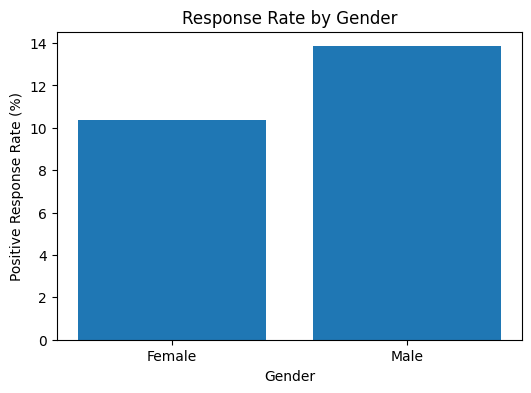

Gender
Female    10.390241
Male      13.841107
Name: Response, dtype: float64


In [13]:
# Cell 11: Gender vs Response

gender_response = (
    df.groupby("Gender")["Response"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

plt.bar(
    gender_response.index,
    gender_response.values
)

plt.title("Response Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Positive Response Rate (%)")

plt.show()

print(gender_response)

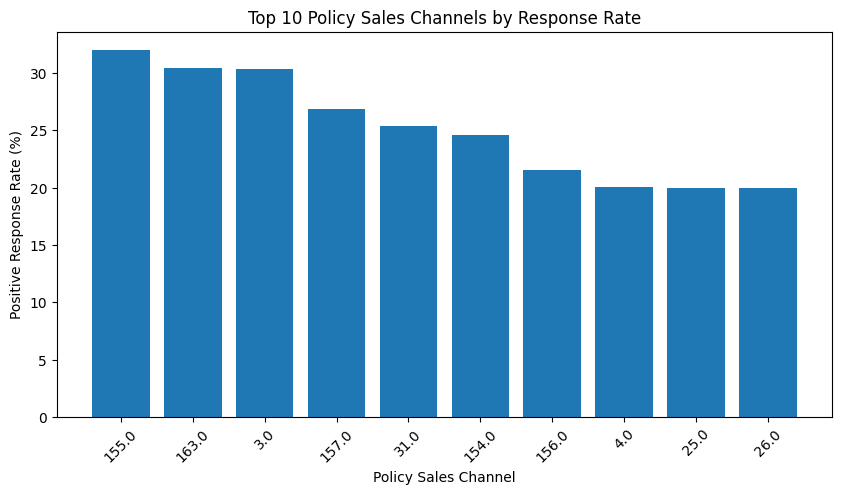

                      count  Response_Rate
Policy_Sales_Channel                      
155.0                  1234      32.009724
163.0                  2893      30.418251
3.0                     523      30.401530
157.0                  6684      26.840215
31.0                    631      25.356577
154.0                  5993      24.595361
156.0                 10661      21.545821
4.0                     509      20.039293
25.0                   1848      19.967532
26.0                  79700      19.938519


In [14]:
# Cell 12: Policy Sales Channel vs Response

channel_response = (
    df.groupby("Policy_Sales_Channel")["Response"]
    .agg(["mean", "count"])
)

channel_response["Response_Rate"] = channel_response["mean"] * 100

# Keep channels with enough customers
channel_response = channel_response[channel_response["count"] >= 500]

top_channels = (
    channel_response
    .sort_values("Response_Rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    top_channels.index.astype(str),
    top_channels["Response_Rate"]
)

plt.title("Top 10 Policy Sales Channels by Response Rate")
plt.xlabel("Policy Sales Channel")
plt.ylabel("Positive Response Rate (%)")
plt.xticks(rotation=45)

plt.show()

print(top_channels[["count", "Response_Rate"]])

In [15]:
# Cell 13: Prepare Features and Target

# Drop ID because it is only an identifier
X = df.drop(columns=["id", "Response"])

# Target
y = df["Response"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nCategorical Columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical Columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Feature Shape: (381109, 10)
Target Shape: (381109,)

Categorical Columns:
['Gender', 'Vehicle_Age', 'Vehicle_Damage']

Numerical Columns:
['Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage']


In [16]:
# Cell 14: Encode categorical variables and split data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ["Gender", "Vehicle_Age", "Vehicle_Damage"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Features: (304887, 10)
Testing Features: (76222, 10)

Training Target Distribution:
Response
0    87.743656
1    12.256344
Name: proportion, dtype: float64

Testing Target Distribution:
Response
0    87.743696
1    12.256304
Name: proportion, dtype: float64


In [17]:
# Cell 15: Logistic Regression Baseline Model

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Results
----------------------------------------
Accuracy : 0.6398939938600404
Precision: 0.25066101134736146
Recall   : 0.9742025262256476
F1 Score : 0.3987294633077766
ROC-AUC  : 0.8357125694886189

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.97      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222



In [18]:
# Cell 15B: Improved Logistic Regression with Scaling

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_cols = ["Gender", "Vehicle_Age", "Vehicle_Damage"]

numeric_cols = [
    "Age",
    "Driving_License",
    "Region_Code",
    "Previously_Insured",
    "Annual_Premium",
    "Policy_Sales_Channel",
    "Vintage"
]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

log_model_scaled = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model_scaled.fit(X_train, y_train)

y_pred_log_scaled = log_model_scaled.predict(X_test)
y_prob_log_scaled = log_model_scaled.predict_proba(X_test)[:, 1]

print("Scaled Logistic Regression Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_log_scaled))
print("Precision:", precision_score(y_test, y_pred_log_scaled))
print("Recall   :", recall_score(y_test, y_pred_log_scaled))
print("F1 Score :", f1_score(y_test, y_pred_log_scaled))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_log_scaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_scaled))

Scaled Logistic Regression Results
----------------------------------------
Accuracy : 0.6407992443126657
Precision: 0.2511108044708155
Recall   : 0.9739884393063584
F1 Score : 0.39928033876736074
ROC-AUC  : 0.8385181548780575

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.59      0.74     66880
           1       0.25      0.97      0.40      9342

    accuracy                           0.64     76222
   macro avg       0.62      0.78      0.57     76222
weighted avg       0.90      0.64      0.70     76222



In [19]:
# Cell 16: Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy : 0.70087376348036
Precision: 0.2810425614994143
Recall   : 0.924534360950546
F1 Score : 0.4310525527773619
ROC-AUC  : 0.8546788923485948

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     66880
           1       0.28      0.92      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222



In [20]:
# Cell 17: Compare Models

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_scaled),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log_scaled),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log_scaled),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log_scaled),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log_scaled),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.640799,0.251111,0.973988,0.399280,0.838518
1,Random Forest,0.700874,0.281043,0.924534,0.431053,0.854679


In [21]:
# Cell 18: Lead Scoring

# Create a copy of the test data
lead_scores = X_test.copy()

# Add actual response
lead_scores["Actual_Response"] = y_test.values

# Add predicted probability from Random Forest
lead_scores["Lead_Score"] = y_prob_rf

# Convert probability into percentage
lead_scores["Lead_Score_Percent"] = lead_scores["Lead_Score"] * 100

# Create lead priority groups
def lead_priority(score):
    if score >= 0.70:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

lead_scores["Lead_Priority"] = lead_scores["Lead_Score"].apply(lead_priority)

# Sort customers from highest to lowest probability
lead_scores = lead_scores.sort_values(
    by="Lead_Score",
    ascending=False
)

lead_scores.head(10)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Actual_Response,Lead_Score,Lead_Score_Percent,Lead_Priority
57590,Male,31,1,28.0,0,< 1 Year,Yes,33197.0,124.0,11,0,0.866699,86.669897,High
4833,Male,46,1,28.0,0,> 2 Years,Yes,54271.0,26.0,287,0,0.858445,85.844545,High
79272,Male,45,1,28.0,0,> 2 Years,Yes,55602.0,26.0,269,1,0.857605,85.760509,High
279813,Male,47,1,28.0,0,> 2 Years,Yes,81742.0,26.0,183,1,0.856382,85.638197,High
75133,Male,48,1,28.0,0,> 2 Years,Yes,57875.0,26.0,262,1,0.855475,85.547470,High
130329,Female,48,1,28.0,0,< 1 Year,Yes,32474.0,26.0,108,1,0.855474,85.547363,High
331362,Male,40,1,28.0,0,> 2 Years,Yes,57673.0,26.0,287,0,0.854089,85.408853,High
112996,Male,52,1,28.0,0,> 2 Years,Yes,74116.0,26.0,201,1,0.853707,85.370673,High
316955,Male,46,1,28.0,0,> 2 Years,Yes,72554.0,26.0,89,0,0.852851,85.285125,High
292884,Male,42,1,28.0,0,> 2 Years,Yes,53994.0,26.0,223,1,0.852809,85.280861,High


In [22]:
# Cell 19: Lead Priority Summary

priority_summary = lead_scores["Lead_Priority"].value_counts()

print("Lead Priority Distribution:")
print(priority_summary)

print("\nLead Priority Percentage:")
print(lead_scores["Lead_Priority"].value_counts(normalize=True) * 100)

Lead Priority Distribution:
Lead_Priority
Low       42175
High      20227
Medium    13820
Name: count, dtype: int64

Lead Priority Percentage:
Lead_Priority
Low       55.331794
High      26.536958
Medium    18.131248
Name: proportion, dtype: float64


In [23]:
# Cell 20: Actual Response Rate by Lead Priority

priority_performance = (
    lead_scores.groupby("Lead_Priority")["Actual_Response"]
    .agg(["count", "mean"])
)

priority_performance["Actual_Response_Rate_%"] = (
    priority_performance["mean"] * 100
)

print(priority_performance)

               count      mean  Actual_Response_Rate_%
Lead_Priority                                         
High           20227  0.332476               33.247639
Low            42175  0.008014                0.801423
Medium         13820  0.164906               16.490593


In [24]:
# Cell 21: Export Lead Scoring Results

final_leads = lead_scores[
    [
        "Gender",
        "Age",
        "Previously_Insured",
        "Vehicle_Age",
        "Vehicle_Damage",
        "Annual_Premium",
        "Policy_Sales_Channel",
        "Lead_Score_Percent",
        "Lead_Priority",
        "Actual_Response"
    ]
]

final_leads.to_csv("insurance_lead_scoring_results.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [25]:
from google.colab import files
files.download("insurance_lead_scoring_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Results

## Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.641 | 0.251 | 0.974 | 0.399 | 0.839 |
| Random Forest | 0.701 | 0.281 | 0.925 | 0.431 | 0.855 |

Random Forest was selected as the final model because it achieved better overall performance in Accuracy, Precision, F1-Score, and ROC-AUC while maintaining high Recall.

## Lead Priority Results

- High Priority Leads: 20,227
- Medium Priority Leads: 13,820
- Low Priority Leads: 42,175

### Actual Response Rate
- High Priority: 33.25%
- Medium Priority: 16.49%
- Low Priority: 0.80%

## Business Insight
The model successfully ranked customers into meaningful lead-priority groups. High-priority customers had a much higher actual response rate than Medium and Low-priority groups, which suggests that sales teams could focus their outreach on High and Medium-priority leads to improve campaign efficiency.